# 1. post performance clustring 

## Goal : Group posts into natural performance types.

## 1.1 GMM Cluster Tuning (Auto-select Cluster Count)

This section fits Gaussian Mixture Models (GMM) across multiple `k` values and covariance types, then selects the best model using **lowest BIC**.

In [731]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# Fast, explicit load (avoid heavy path-search logic)
DATA_PATH = r"C:\users\hanib\data_mining -project\marketing\data\data_processed.json"
# C:\users\hanib\data_mining -project\marketing\jsons\all_final_appended.json
#C:\users\hanib\data_mining -project\marketing\data\data_processed.json
try:
    df_gmm = pd.read_json(DATA_PATH)
except ValueError:
    df_gmm = pd.read_json(DATA_PATH, lines=True)

base_cols = ["followers_count", "likes_count", "comments_count", "views_count"]
missing_base = [c for c in base_cols if c not in df_gmm.columns]
if missing_base:
    raise ValueError(f"Missing required columns in df_gmm: {missing_base}")

df_small = df_gmm[base_cols].copy()
print('Loaded rows:', len(df_small))



Loaded rows: 710


In [732]:
import matplotlib.pyplot as plt

if all(v in globals() for v in ['gmm_tuning_results', 'best_covariance']):
    best_cov_df = gmm_tuning_results[gmm_tuning_results["covariance_type"] == best_covariance].sort_values("k")
    fig, ax1 = plt.subplots(figsize=(8, 4))
    ax1.plot(best_cov_df["k"], best_cov_df["bic"], marker="o", label="BIC")
    ax1.plot(best_cov_df["k"], best_cov_df["aic"], marker="s", label="AIC")
    ax1.set_xlabel("Number of clusters (k)")
    ax1.set_ylabel("Information Criterion")
    ax1.set_title(f"GMM tuning for covariance={best_covariance}")
    ax1.legend(loc="upper left")

    ax2 = ax1.twinx()
    ax2.plot(best_cov_df["k"], best_cov_df["silhouette"], color="tab:green", marker="^", linestyle="--", label="Silhouette")
    ax2.set_ylabel("Silhouette")
    ax2.legend(loc="upper right")

    plt.tight_layout()
    plt.show()
else:
    print("Skipping GMM plot: run GMM tuning cell first or ignore this section.")



Skipping GMM plot: run GMM tuning cell first or ignore this section.


In [733]:
from sklearn.manifold import TSNE
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

if all(v in globals() for v in ['X_gmm_scaled', 'best_labels', 'best_k', 'best_covariance']):
    tsne_gmm = TSNE(n_components=2, random_state=42, perplexity=30, init='pca', learning_rate='auto')
    X_gmm_tsne = tsne_gmm.fit_transform(X_gmm_scaled)

    gmm_tsne_df = pd.DataFrame({
        'tsne_1': X_gmm_tsne[:, 0],
        'tsne_2': X_gmm_tsne[:, 1],
        'gmm_cluster': pd.Series(best_labels).astype(int)
    })

    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        data=gmm_tsne_df,
        x='tsne_1',
        y='tsne_2',
        hue='gmm_cluster',
        palette='tab10',
        alpha=0.8
    )
    plt.title(f'GMM Clusters t-SNE (k={best_k}, covariance={best_covariance})')
    plt.xlabel('t-SNE 1')
    plt.ylabel('t-SNE 2')
    plt.legend(title='GMM Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print("Skipping GMM t-SNE: run GMM section first or ignore this section.")



Skipping GMM t-SNE: run GMM section first or ignore this section.


In [734]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

DATA_PATH = r"C:\users\hanib\data_mining -project\marketing\data\processed\kpi_dataset.json"
#C:\users\hanib\data_mining -project\marketing\data\processed\kpi_dataset.json
try:
    df = pd.read_json(DATA_PATH)
except ValueError:
    df = pd.read_json(DATA_PATH, lines=True)

cols = ["followers_count", "likes_count", "comments_count", "views_count" , "engagement_rate" , "view_rate" , "view_engagement_rate" ]
missing = [c for c in cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df_small = df[cols].copy()
print('Loaded rows:', len(df_small))
df_small.head(100)



Loaded rows: 709


,followers_count,likes_count,comments_count,views_count,engagement_rate,view_rate,view_engagement_rate
0,4392,13.0,0,1391,0.002960,0.316712,0.009346
1,4392,60.0,0,20300,0.013661,4.622040,0.002956
2,4392,250.0,4,52500,0.057832,11.953552,0.004838
3,4392,87.0,0,1200000,0.019809,273.224044,0.000073
4,4392,97.0,0,706000,0.022086,160.746812,0.000137
...,...,...,...,...,...,...,...
95,77000,1.0,0,403,0.000013,0.005234,0.002481
96,77000,35.0,1,9600,0.000468,0.124675,0.003750
97,77000,18.0,0,7100,0.000234,0.092208,0.002535
98,77000,823.0,4,15000,0.010740,0.194805,0.055133


In [735]:
df_small.describe()


,followers_count,likes_count,comments_count,views_count,engagement_rate,view_rate,view_engagement_rate
count,7.090000e+02,709.000000,709.000000,7.090000e+02,709.000000,709.000000,709.000000
mean,1.003026e+06,7640.973202,191.435825,3.690546e+05,0.020668,8.656995,0.018513
std,3.265699e+06,36440.554800,1119.916405,1.529415e+06,0.097991,44.809186,0.073718
min,7.390000e+02,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,6.300000e+03,5.000000,0.000000,1.391000e+03,0.000222,0.055144,0.001745
50%,2.500000e+04,27.000000,1.000000,7.677000e+03,0.001607,0.284091,0.006652
75%,8.100000e+04,196.000000,4.000000,4.585400e+04,0.008333,1.000000,0.016250
max,1.500000e+07,483000.000000,14000.000000,2.040000e+07,1.370025,646.153846,1.514286


In [736]:
df_small.isnull().sum()


followers_count         0
likes_count             0
comments_count          0
views_count             0
engagement_rate         0
view_rate               0
view_engagement_rate    0
dtype: int64

In [737]:
df_small["views_count"] = pd.to_numeric(df_small["views_count"], errors="coerce")
df_small["views_count"] = df_small["views_count"].fillna(0)
df_small["views_count"] = df_small["views_count"].clip(lower=0)
df_small.isnull().sum()


followers_count         0
likes_count             0
comments_count          0
views_count             0
engagement_rate         0
view_rate               0
view_engagement_rate    0
dtype: int64

In [738]:
df_small.duplicated().sum()


np.int64(42)

In [739]:
# df_small['engagement'] = df_small['likes_count'] + df_small['comments_count']
# df_small['engagement_rate'] = np.where(
#     df_small['followers_count'] > 0,
#       df_small['engagement'] / df_small['followers_count'],
#         0
#     )
# df_small['comment_rate'] = np.where(
#     df_small['followers_count'] > 0,
#       df_small['comments_count'] / df_small['followers_count'],
#         0
#     )   
# df_small['view_rate'] = np.where(
#     df_small['followers_count'] > 0,
#       df_small['views_count'] / df_small['followers_count'],
#         0
#     )
# df_small['view_engagement_rate'] = np.where(
#     df_small['views_count'] > 0,
#       df_small['engagement'] / df_small['views_count'],
#         0
#     )
df_small['comments_to_likes_ratio'] = np.where(
    df_small['likes_count'] > 0,
      df_small['comments_count'] / df_small['likes_count'],
        0
    )


In [740]:
df_small.head()


,followers_count,likes_count,comments_count,views_count,engagement_rate,view_rate,view_engagement_rate,comments_to_likes_ratio
0,4392,13.0,0,1391,0.002960,0.316712,0.009346,0.000
1,4392,60.0,0,20300,0.013661,4.622040,0.002956,0.000
2,4392,250.0,4,52500,0.057832,11.953552,0.004838,0.016
3,4392,87.0,0,1200000,0.019809,273.224044,0.000073,0.000
4,4392,97.0,0,706000,0.022086,160.746812,0.000137,0.000


In [741]:
df_small.columns


Index(['followers_count', 'likes_count', 'comments_count', 'views_count',
       'engagement_rate', 'view_rate', 'view_engagement_rate',
       'comments_to_likes_ratio'],
      dtype='object')

In [742]:
print(df_small["comments_count"].value_counts())


comments_count
0      306
1      117
2       51
4       39
3       29
      ... 
770      1
34       1
69       1
27       1
83       1
Name: count, Length: 99, dtype: int64


In [758]:
features = [
    "engagement_rate", # likes comments as a percentage of followers
    "view_rate", # views as a percentage of followers
    "view_engagement_rate", # of those who saw it, how many engaged 
    "comments_to_likes_ratio" # comments as a percentage of likes
]


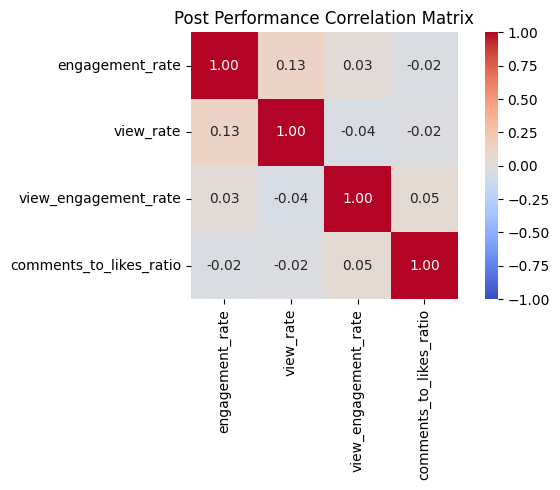

In [759]:
corr = df_small[features].corr(numeric_only=True)

plt.figure(figsize=(7, 5))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    square=True
)
plt.title("Post Performance Correlation Matrix")
plt.tight_layout()
plt.show()


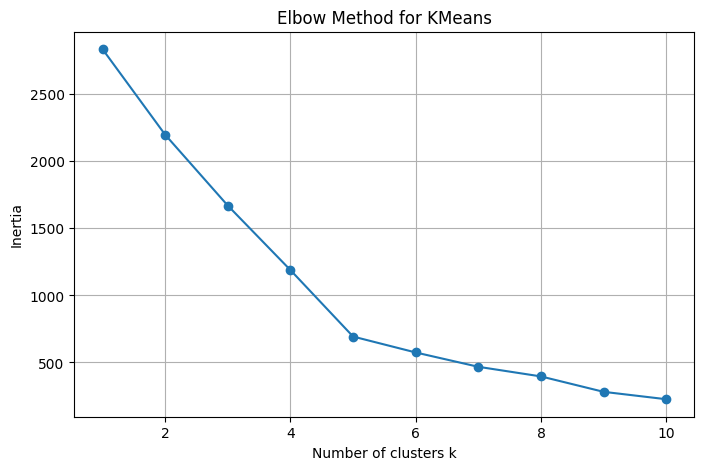

In [744]:
inertias = []
# Elbow method to find the optimal number of clusters
X = df_small[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
inertia = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker="o")
plt.xlabel("Number of clusters k")
plt.ylabel("Inertia")
plt.title("Elbow Method for KMeans")
plt.grid(True)
plt.show()


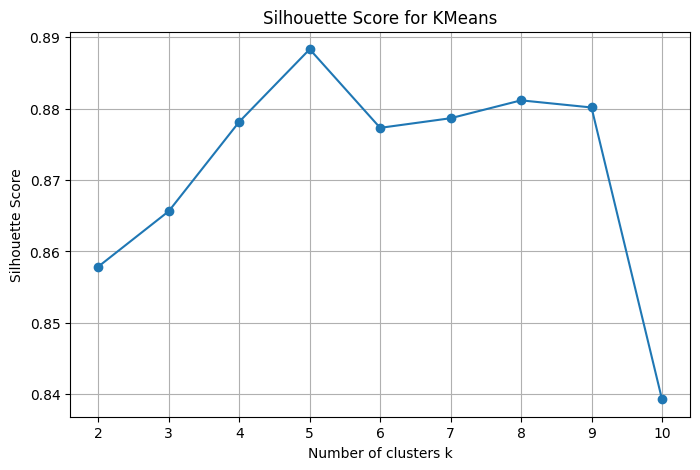

In [745]:
from sklearn.metrics import silhouette_score
silhouette_scores = []
K_range = range(2, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores, marker="o")
plt.xlabel("Number of clusters k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for KMeans")
plt.grid(True)
plt.show()


In [746]:
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)
print("number of iterations:", kmeans.n_iter_)


number of iterations: 6


In [747]:
# Assign cluster label to each row
df_small['cluster'] = kmeans_labels
df_small[['cluster'] + features].head(770)


,cluster,engagement_rate,view_rate,view_engagement_rate,comments_to_likes_ratio
0,0,0.002960,0.316712,0.009346,0.000000
1,0,0.013661,4.622040,0.002956,0.000000
2,0,0.057832,11.953552,0.004838,0.016000
3,1,0.019809,273.224044,0.000073,0.000000
4,1,0.022086,160.746812,0.000137,0.000000
...,...,...,...,...,...
704,0,0.007472,0.637194,0.011726,0.028571
705,0,0.003217,0.306663,0.010491,0.000000
706,0,0.003217,0.088522,0.036342,0.000000
707,0,0.009236,0.908261,0.010169,0.000000


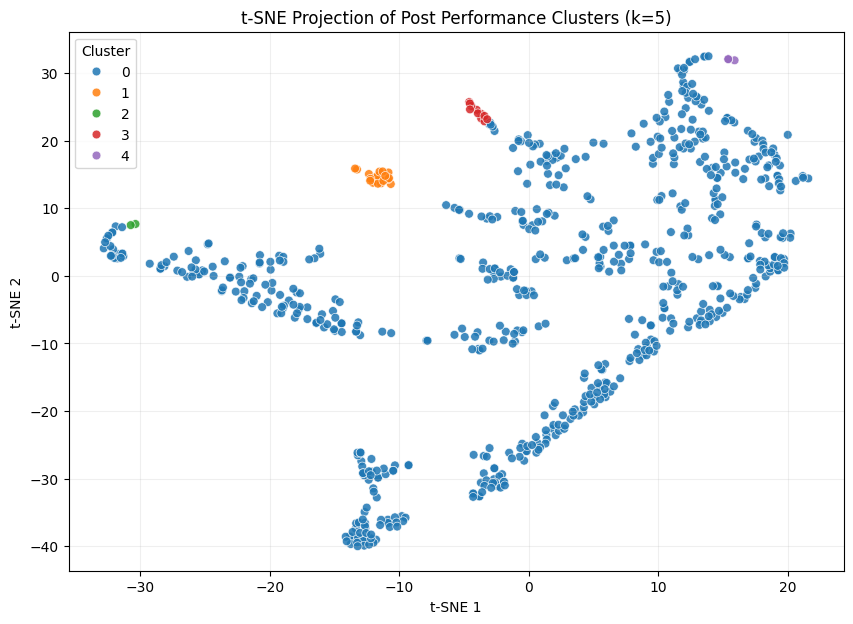

In [748]:
from sklearn.manifold import TSNE
import seaborn as sns
# t-SNE on the same scaled clustering features
tsne = TSNE(n_components=2, random_state=42, perplexity=30, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_scaled)
df_tsne = pd.DataFrame(X_tsne, columns=['tsne_1', 'tsne_2'])
df_tsne['cluster'] = df_small['cluster'].values
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_tsne, x='tsne_1', y='tsne_2', hue='cluster', palette='tab10', s=40, alpha=0.85)
plt.title('t-SNE Projection of Post Performance Clusters (k=5)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(title='Cluster')
plt.grid(True, alpha=0.2)
plt.show()


In [749]:
# DBSCAN is run manually in the next cell using EPS and MIN_SAMPLES.


{'eps': 1.7, 'min_samples': 7}
n_clusters: 2 | noise_ratio: 0.018
dbscan_cluster
-1     13
 0    679
 1     17
Name: count, dtype: int64


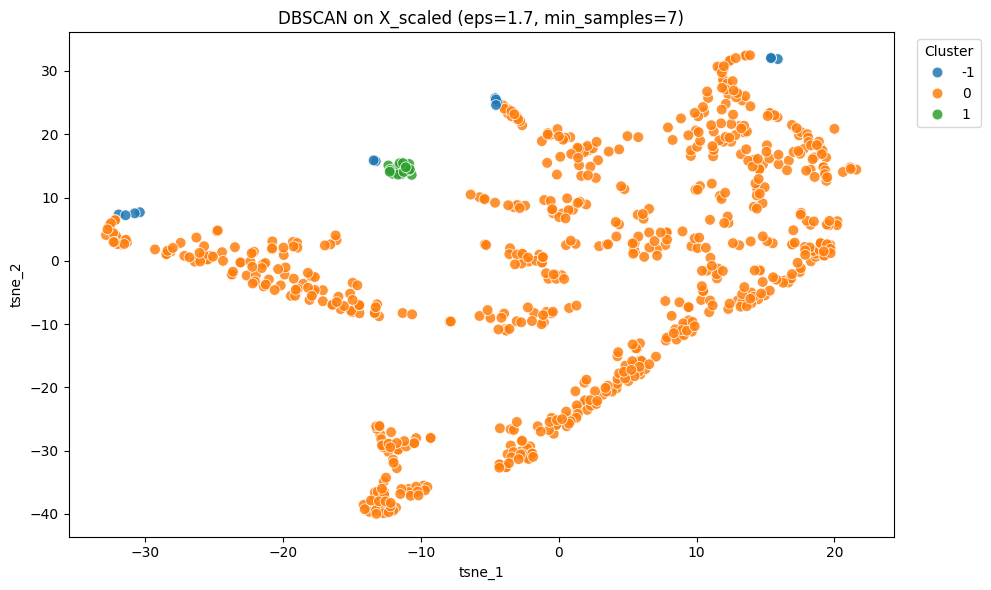

In [773]:
EPS = 1.7
MIN_SAMPLES = 7

# 1) DBSCAN on original scaled feature space
db = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES)
labels = db.fit_predict(X_scaled)

df_small["dbscan_cluster"] = labels
n_clusters = len(set(labels) - {-1})
noise_ratio = (labels == -1).mean()

print({"eps": EPS, "min_samples": MIN_SAMPLES})
print("n_clusters:", n_clusters, "| noise_ratio:", round(float(noise_ratio), 3))
print(df_small["dbscan_cluster"].value_counts().sort_index())

# 2) t-SNE only for visualization
perplexity = max(5, min(30, len(X_scaled)//10))
tsne_db = TSNE(
    n_components=2,
    random_state=42,
    perplexity=perplexity,
    learning_rate="auto",
    init="pca"
)
X2_db = tsne_db.fit_transform(X_scaled)

plot_df = pd.DataFrame({
    "tsne_1": X2_db[:, 0],
    "tsne_2": X2_db[:, 1],
    "dbscan_cluster": df_small["dbscan_cluster"].values
})

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=plot_df,
    x="tsne_1", y="tsne_2",
    hue="dbscan_cluster",
    palette="tab10",
    s=60, alpha=0.85
)
plt.title(f"DBSCAN on X_scaled (eps={EPS}, min_samples={MIN_SAMPLES})")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [751]:

# Cluster meaning report for post_performance_clustring
# Works for DBSCAN/KMeans cluster columns in df_small

cluster_col = None
for c in ['dbscan_cluster_tuned', 'dbscan_cluster', 'kmeans_cluster_tuned', 'cluster']:
    if c in df_small.columns:
        cluster_col = c
        break

if cluster_col is None:
    raise ValueError("No cluster column found in `df_small`. Run clustering cell first.")

print("Using cluster column:", cluster_col)

metrics = [
    "engagement_rate",
    "view_rate",
    "view_engagement_rate",
    "comments_to_likes_ratio"
]

missing = [m for m in metrics if m not in df_small.columns]
if missing:
    raise ValueError(f"Missing metric columns: {missing}")

summary = (
    df_small.groupby(cluster_col)
    .agg(
        posts_count=(cluster_col, "size"),
        avg_engagement_rate=("engagement_rate", "mean"),
        avg_view_rate=("view_rate", "mean"),
        avg_view_engagement_rate=("view_engagement_rate", "mean"),
        avg_comments_to_likes_ratio=("comments_to_likes_ratio", "mean"),
    )
    .reset_index()
    .sort_values(cluster_col)
)

for c in ["avg_engagement_rate", "avg_view_rate", "avg_view_engagement_rate", "avg_comments_to_likes_ratio"]:
    summary[c] = summary[c].round(4)

print("Cluster summary table:")
display(summary)

# Reference quantiles for plain-language meaning
q = {m: (df_small[m].quantile(0.33), df_small[m].quantile(0.67)) for m in metrics}

def level(val, lo, hi):
    if val <= lo:
        return "low"
    if val >= hi:
        return "high"
    return "medium"

print("Cluster meaning:")
for _, row in summary.iterrows():
    cid = int(row[cluster_col])

    if cid == -1:
        meaning = "Noise/outlier posts (outside dense behavior groups)"
    else:
        e = level(row["avg_engagement_rate"], *q["engagement_rate"])
        v = level(row["avg_view_rate"], *q["view_rate"])
        ve = level(row["avg_view_engagement_rate"], *q["view_engagement_rate"])
        c2l = level(row["avg_comments_to_likes_ratio"], *q["comments_to_likes_ratio"])
        meaning = f"{e} engagement, {v} reach, {ve} engagement-per-view, {c2l} comments-vs-likes"

    print(f"Cluster {cid}: {meaning} | posts={int(row['posts_count'])}")

Using cluster column: dbscan_cluster
Cluster summary table:


,dbscan_cluster,posts_count,avg_engagement_rate,avg_view_rate,avg_view_engagement_rate,avg_comments_to_likes_ratio
0,0,473,0.0289,2.5581,0.0255,0.0140
1,1,19,0.0338,251.1807,0.0002,0.0431
2,2,66,0.0001,0.5356,0.0002,0.0000
3,3,129,0.0024,0.8658,0.0073,0.6779
4,4,22,0.0018,0.3794,0.0058,0.0468


Cluster meaning:
Cluster 0: high engagement, high reach, high engagement-per-view, medium comments-vs-likes | posts=473
Cluster 1: high engagement, high reach, low engagement-per-view, high comments-vs-likes | posts=19
Cluster 2: low engagement, medium reach, low engagement-per-view, low comments-vs-likes | posts=66
Cluster 3: medium engagement, high reach, medium engagement-per-view, high comments-vs-likes | posts=129
Cluster 4: medium engagement, medium reach, medium engagement-per-view, high comments-vs-likes | posts=22


ask about clustring 0 and 6 they are simelar and i couldnt do anything about them i could merge them maually but i want the approval 


- Cluster 0: Top Performers (High Reach + High Engagement)
- Cluster 1: Niche Loyal Audience (High Engagement, Low Reach)
- Cluster 2: Awareness Performers (High Reach, Mid Engagement)
- Cluster 3: Underperforming Reach-Limited Posts
- Cluster 4: Conversation Drivers (High Reach + Strong Comment Quality)
- Cluster 5: Low-Impact Posts
- Cluster 6: Elite Viral Posts (Small but Very High Performance)



check the view rate 


understand why i use the coulms and why 

In [752]:
# Setup for cluster profiling cells
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

# Keep original full dataframe (if present) and a working dataframe
base_df = df.copy() if 'df' in globals() else None
df = df_small.copy() if 'df_small' in globals() else df.copy()

# Bring metadata/content columns back from base_df when df_small dropped them
needed_extra = ['post_type_std', 'post_type', 'sector', 'industry', 'caption_length', 'hashtags_count', 'emoji_count', 'CTA_present', 'promo_post', 'mentions_location']
if base_df is not None and len(base_df) == len(df):
    for c in needed_extra:
        if c not in df.columns and c in base_df.columns:
            df[c] = base_df[c].values

# Ensure cluster column exists
if 'dbscan_cluster' not in df.columns:
    feature_cols = [c for c in ['engagement_rate', 'view_rate', 'view_engagement_rate', 'comments_to_likes_ratio'] if c in df.columns]
    if len(feature_cols) < 2:
        numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in ['dbscan_cluster', 'kmeans_cluster_raw', 'cluster']]
        feature_cols = numeric_cols[:4]
    if len(feature_cols) < 2:
        raise ValueError('Not enough numeric features to build dbscan_cluster. Run your clustering cell first.')
    X = df[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
    X_scaled = StandardScaler().fit_transform(X)
    df['dbscan_cluster'] = DBSCAN(eps=0.7, min_samples=10).fit_predict(X_scaled)

# Normalize key columns used in your 5 profiling cells
if 'post_type_std' not in df.columns:
    if 'post_type' in df.columns:
        df['post_type_std'] = df['post_type']
    else:
        df['post_type_std'] = 'unknown'

if 'sector' not in df.columns:
    if 'industry' in df.columns:
        df['sector'] = df['industry']
    else:
        df['sector'] = 'unknown'

if 'engagement_rate' not in df.columns and 'avg_engagement_rate' in df.columns:
    df['engagement_rate'] = df['avg_engagement_rate']
elif 'engagement_rate' not in df.columns:
    df['engagement_rate'] = 0.0

# Do not force fake zeros for content columns; keep NaN if genuinely missing
for c in ['caption_length', 'hashtags_count', 'emoji_count', 'CTA_present', 'promo_post', 'mentions_location']:
    if c not in df.columns:
        df[c] = np.nan

print('Ready. df shape:', df.shape)
print('dbscan_cluster counts:')
print(df['dbscan_cluster'].value_counts(dropna=False).sort_index())
print('Available profiling columns:')
print([c for c in ['post_type_std','sector','engagement_rate','caption_length','hashtags_count','emoji_count','CTA_present','promo_post','mentions_location'] if c in df.columns])


Ready. df shape: (709, 19)
dbscan_cluster counts:
dbscan_cluster
0    473
1     19
2     66
3    129
4     22
Name: count, dtype: int64
Available profiling columns:
['post_type_std', 'sector', 'engagement_rate', 'caption_length', 'hashtags_count', 'emoji_count', 'CTA_present', 'promo_post', 'mentions_location']


In [753]:
# 1. Cluster size
df['dbscan_cluster'].value_counts()

dbscan_cluster
0    473
3    129
2     66
4     22
1     19
Name: count, dtype: int64

In [754]:
# 2. Post type distribution per cluster
pd.crosstab(df['dbscan_cluster'], df['post_type_std'], normalize='index') * 100

post_type_std,post,reel
dbscan_cluster,,
0,10.147992,89.852008
1,68.421053,31.578947
2,10.606061,89.393939
3,34.883721,65.116279
4,9.090909,90.909091


In [755]:
# 3. Sector distribution per cluster
pd.crosstab(df['dbscan_cluster'], df['sector'], normalize='index') * 100

sector,Cafes/Restaurants,Fashion,Gym,Influencers,Supermarkets
dbscan_cluster,,,,,
0,26.849894,37.209302,8.45666,16.490486,10.993658
1,89.473684,10.526316,0.00000,0.000000,0.000000
2,16.666667,83.333333,0.00000,0.000000,0.000000
3,55.813953,30.232558,0.00000,0.775194,13.178295
4,27.272727,40.909091,0.00000,4.545455,27.272727


In [756]:
# 4. Best 5 posts inside each cluster
df.sort_values(['dbscan_cluster', 'engagement_rate'], ascending=[True, False]).groupby('dbscan_cluster').head(5)


,followers_count,likes_count,comments_count,views_count,engagement_rate,view_rate,view_engagement_rate,comments_to_likes_ratio,cluster,dbscan_cluster,post_type,sector,caption_length,hashtags_count,emoji_count,CTA_present,promo_post,mentions_location,post_type_std
648,2362,3221.0,15,127000,1.370025,53.767993,0.025480,0.004657,3,0,reel,Supermarkets,176,0,8,True,False,True,reel
655,2362,2609.0,14,140000,1.110500,59.271804,0.018736,0.005366,3,0,reel,Supermarkets,190,1,5,True,False,True,reel
653,2362,2164.0,4,82300,0.917866,34.843353,0.026343,0.001848,3,0,reel,Supermarkets,185,1,6,True,False,True,reel
660,2362,1678.0,83,274000,0.745555,116.003387,0.006427,0.049464,3,0,reel,Supermarkets,116,0,3,False,False,True,reel
646,2362,1654.0,4,41400,0.701948,17.527519,0.040048,0.002418,3,0,reel,Supermarkets,214,0,6,True,False,True,reel
450,6500,920.0,7,1400000,0.142615,215.384615,0.000662,0.007609,1,1,post,Cafes/Restaurants,178,3,2,True,True,True,post
465,6500,894.0,14,1400000,0.139692,215.384615,0.000649,0.015660,1,1,post,Cafes/Restaurants,87,1,1,True,True,True,post
463,6500,863.0,12,1400000,0.134615,215.384615,0.000625,0.013905,1,1,post,Cafes/Restaurants,87,1,1,True,True,True,post
468,6500,337.0,4,1400000,0.052462,215.384615,0.000244,0.011869,1,1,post,Cafes/Restaurants,77,1,1,True,True,True,post
460,6500,196.0,2,1400000,0.030462,215.384615,0.000141,0.010204,1,1,post,Cafes/Restaurants,317,4,3,True,True,True,post


In [757]:
# 5. Caption/hashtags/emoji/CTA/promo summary
df.groupby('dbscan_cluster').agg({
    'caption_length': 'mean',
    'hashtags_count': 'mean',
    'emoji_count': 'mean',
    'CTA_present': 'mean',
    'promo_post': 'mean',
    'mentions_location': 'mean'
})

,caption_length,hashtags_count,emoji_count,CTA_present,promo_post,mentions_location
dbscan_cluster,,,,,,
0,125.680761,1.093023,2.443975,0.583510,0.693446,0.522199
1,129.631579,1.684211,1.052632,0.842105,0.789474,0.842105
2,153.333333,0.757576,4.333333,0.803030,0.924242,0.651515
3,186.077519,0.480620,3.635659,0.798450,0.883721,0.573643
4,162.181818,1.318182,3.045455,0.818182,0.954545,0.636364
